# Reproduce — Hyena Hierarchy (Nhóm 08, CS2308)

**Mục tiêu:** chứng minh luận điểm cốt lõi của bài Poli et al. (ICML 2023):
> Attention có chi phí **O(L²)**, còn Hyena (long-conv + gating qua **FFT**) gần tuyến tính **O(L·log L)**.

Khi tăng độ dài chuỗi `L`, runtime Attention vọt lên, Hyena tăng chậm.

**Cách dùng:** Colab có sẵn `torch` + `matplotlib` → chỉ cần bấm **Runtime ▸ Run all**. Chạy CPU, vài giây xong.

*Tài liệu kèm: `note.md` (trả lời) · `concept.md` (hiểu sâu) · `slides.md` (slide) · `tasks.md` (phân công).*

In [1]:
# (Colab đã cài sẵn torch + matplotlib. Nếu chạy nơi khác, bỏ comment dòng dưới)
# !pip install torch matplotlib

import time
import torch
import torch.nn as nn

torch.manual_seed(0)
DEVICE = "cpu"  # CPU đủ nhanh cho demo; ổn định & nhẹ RAM
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.12.0 | device: cpu


## 1) Hyena Operator (thuần PyTorch, ~40 dòng)
Bậc 2: xen kẽ **long-convolution** (qua FFT) và **element-wise gating** (phụ thuộc input).

In [2]:
class HyenaOperator(nn.Module):
    def __init__(self, d_model, order=2, filter_len=256):
        super().__init__()
        self.order = order
        # N+1 phep chieu tuyen tinh cua input: (v, x^1, ..., x^N)
        self.in_proj = nn.Linear(d_model, (order + 1) * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        # 'implicit filter': bo loc dai, o ban demo hoc truc tiep filter ngan cho moi tang
        self.filters = nn.Parameter(torch.randn(order, d_model, filter_len) * 0.02)

    def fft_conv(self, x, h):
        # x: (B, D, L) ; h: (D, Lh) -> tich chap theo chieu L bang FFT
        L = x.shape[-1]
        fft_len = 2 * L  # zero-pad de tich chap tuyen tinh (tranh wrap-around)
        x_f = torch.fft.rfft(x, n=fft_len)
        h_f = torch.fft.rfft(h, n=fft_len)
        # nhan o mien tan so == convolution o mien thoi gian
        return torch.fft.irfft(x_f * h_f, n=fft_len)[..., :L]

    def forward(self, u):
        B, L, D = u.shape
        parts = self.in_proj(u).split(D, dim=-1)   # (order+1) tensor (B, L, D)
        v = parts[0].transpose(1, 2)               # (B, D, L)
        for n in range(self.order):
            x_n = parts[n + 1].transpose(1, 2)     # gate phu thuoc input
            v = x_n * self.fft_conv(v, self.filters[n])  # gate( long_conv(v) )
        return self.out_proj(v.transpose(1, 2))    # (B, L, D)

## 2) Attention thuần (để so sánh chi phí O(L²))
Dòng `q @ k.T` tạo ma trận `L×L` — chính là nguồn của O(L²).

In [3]:
class SimpleAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.scale = d_model ** -0.5

    def forward(self, u):
        B, L, D = u.shape
        q, k, v = self.qkv(u).split(D, dim=-1)
        scores = (q @ k.transpose(-2, -1)) * self.scale  # (B, L, L) <- O(L^2)!
        attn = scores.softmax(dim=-1)
        return self.out_proj(attn @ v)

## 3) Đo runtime theo độ dài chuỗi L

In [4]:
def bench(model, B, L, D, repeats=3):
    x = torch.randn(B, L, D, device=DEVICE)
    with torch.no_grad():
        model(x)  # warm-up
        t0 = time.perf_counter()
        for _ in range(repeats):
            model(x)
        return (time.perf_counter() - t0) / repeats * 1000  # ms

B, D = 1, 64
Ls = [256, 512, 1024, 2048, 4096]   # tang 8192 neu muon duong cong kich tinh hon

hyena = HyenaOperator(D, order=2).to(DEVICE).eval()
attn  = SimpleAttention(D).to(DEVICE).eval()

print(f"device={DEVICE} | batch={B}, d_model={D}\n")
print(f"{'L':>6} | {'Attention (ms)':>15} | {'Hyena (ms)':>12} | {'Hyena nhanh hon':>16}")
print('-' * 62)

L_list, attn_ms, hyena_ms = [], [], []
for L in Ls:
    a, h = bench(attn, B, L, D), bench(hyena, B, L, D)
    L_list.append(L); attn_ms.append(a); hyena_ms.append(h)
    print(f"{L:>6} | {a:>15.2f} | {h:>12.2f} | {a/h:>15.2f}x")

device=cpu | batch=1, d_model=64

     L |  Attention (ms) |   Hyena (ms) |  Hyena nhanh hon
--------------------------------------------------------------
   256 |            0.18 |         0.34 |            0.53x
   512 |            0.47 |         0.69 |            0.69x
  1024 |            1.56 |         1.51 |            1.03x
  2048 |            5.21 |         2.88 |            1.81x


  4096 |           22.39 |         7.64 |            2.93x


## 4) Biểu đồ (hiện inline trong Colab)

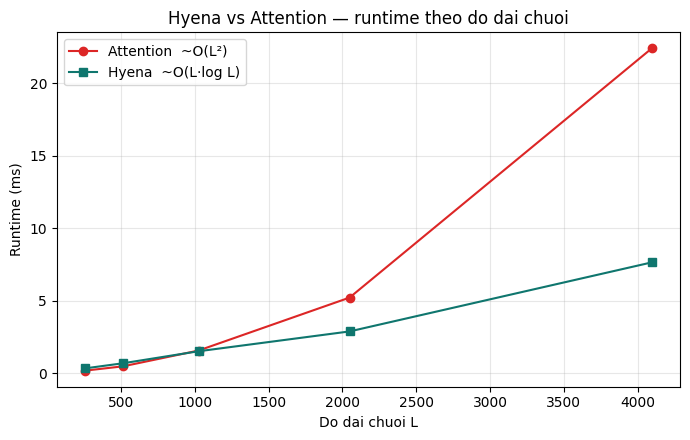


Ket luan:
  - Attention dung ma tran L x L (q @ k^T) -> runtime vot theo L^2.
  - Hyena nhan o mien tan so (FFT) -> runtime tang cham ~ L*log L.
  - L cang dai, Hyena cang thang dam (xem cot "Hyena nhanh hon").


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4.5))
plt.plot(L_list, attn_ms, 'o-', label='Attention  ~O(L\u00b2)', color='#dc2626')
plt.plot(L_list, hyena_ms, 's-', label='Hyena  ~O(L\u00b7log L)', color='#0f766e')
plt.xlabel('Do dai chuoi L'); plt.ylabel('Runtime (ms)')
plt.title('Hyena vs Attention \u2014 runtime theo do dai chuoi')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('reproduce_runtime.png', dpi=130)  # luu de chen vao slide
plt.show()

print('\nKet luan:')
print('  - Attention dung ma tran L x L (q @ k^T) -> runtime vot theo L^2.')
print('  - Hyena nhan o mien tan so (FFT) -> runtime tang cham ~ L*log L.')
print('  - L cang dai, Hyena cang thang dam (xem cot "Hyena nhanh hon").')